# **ADULT INCOME**

## **1. LIBRERÍAS**





In [1]:
!pip install xgboost

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score

from sklearn.metrics import (accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

from sklearn.neighbors import KNeighborsClassifier

from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.model_selection import RandomizedSearchCV

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.initializers import HeNormal
from tensorflow.keras.optimizers import Adam

import time
resultados_finales = []

## **2. LIMPIEZA DEL DATASET**

### **2.1 CARGA DEL DATASET Y EXPLORACIÓN DE VARIABLES**


In [3]:
df = pd.read_csv("adult.csv")
print("Dimensiones del dataset:", df.shape)
df.info()
df.describe()

Dimensiones del dataset: (48842, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


### **2.2 EXPLORACIÓN Y ELIMINACIÓN DE NULOS**


In [4]:
df.replace("?", np.nan, inplace=True)
df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False)
df.dropna(inplace=True)

### **2.3 SEPARACIÓN ENTRE X E Y (VARIABLE OBJETIVO)**

In [5]:
# Se convierte la columna income (variable objetivo) a formato numérico:
# >50K = 1 y <=50K = 0
df["income"] = df["income"].astype(str).str.strip()
df["income"] = df["income"].map({
    ">50K": 1,
    "<=50K": 0
})
df["income"].value_counts()
X = df.drop(columns=["income"])
y = df["income"]
print("Variables predictoras:", X.shape)
print("Variable objetivo:", y.shape)

Variables predictoras: (45222, 14)
Variable objetivo: (45222,)


### **2.4 ONE-HOT ENCODING**

In [6]:
X = pd.get_dummies(X, drop_first=True)
print(X.shape)

(45222, 96)


### **2.4 DIVISIÓN TRAIN-TEST Y ESCALADO**

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train: (36177, 96)
Test: (9045, 96)


### **2.4 FUNCIÓN DE EVALUACIÓN PARA TODOS LOS MODELOS**

In [8]:
def evaluar_modelo(nombre_modelo, modelo, X_test, y_test):
    y_pred = modelo.predict(X_test)

    if hasattr(modelo, "predict_proba"):
        y_proba = modelo.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
    else:
        auc = np.nan

    resultados = {
        "Modelo": nombre_modelo,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "AUC-ROC": auc
    }

    print(f"\n===== {nombre_modelo} =====")
    print(classification_report(y_test, y_pred))
    print("Matriz de confusión:")
    print(confusion_matrix(y_test, y_pred))

    return resultados

## **3. REGRESION LOGÍSTICA**

### **3.1 DEFINICIÓN DE PARÁMETROS**

In [9]:
inicio_lr = time.time()
log_reg = LogisticRegression(
    max_iter=2000,
    random_state=42
)
log_reg.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=2000, random_state=42)

### **3.2 PREDICCIONES Y MÉTRICAS**

In [10]:
y_pred_lr = log_reg.predict(X_test_scaled)
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:,1]
tiempo_lr = time.time() - inicio_lr

accuracy = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr)
recall = recall_score(y_test, y_pred_lr)
f1 = f1_score(y_test, y_pred_lr)
auc = roc_auc_score(y_test, y_prob_lr)

print("===== Regresión logística =====")

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("AUC-ROC:", auc)
print("Tiempo (s):", tiempo_lr)

print("\n===== Classification Report =====\n")
print(classification_report(y_test, y_pred_lr))

resultados_finales.append({
    "Modelo": "Regresión Logística",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1-score": f1,
    "AUC-ROC": auc,
    "Tiempo (s)": tiempo_lr
})

===== Regresión logística =====
Accuracy: 0.845771144278607
Precision: 0.7305389221556886
Recall: 0.5985727029438002
F1-score: 0.6580044128462859
AUC-ROC: 0.904618875835725
Tiempo (s): 0.8975586891174316

===== Classification Report =====

              precision    recall  f1-score   support

           0       0.88      0.93      0.90      6803
           1       0.73      0.60      0.66      2242

    accuracy                           0.85      9045
   macro avg       0.80      0.76      0.78      9045
weighted avg       0.84      0.85      0.84      9045



### **3.3 MATRIZ DE CONFUSIÓN Y CURVA ROC**

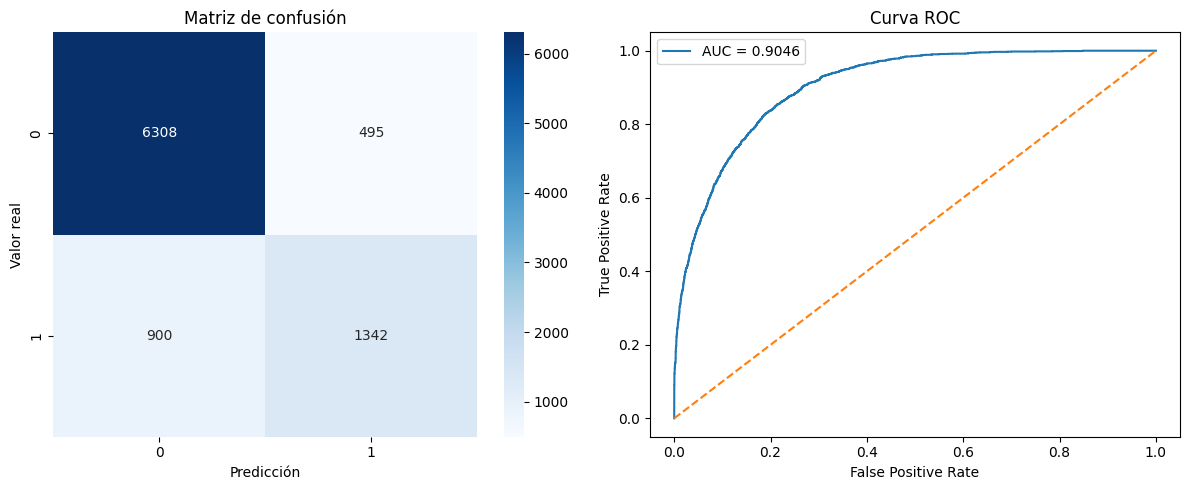

In [11]:
cm = confusion_matrix(y_test, y_pred_lr)
fpr, tpr, thresholds = roc_curve(y_test, y_prob_lr)

auc = roc_auc_score(y_test, y_prob_lr)
fig, ax = plt.subplots(1, 2, figsize=(12,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=ax[0]
)

ax[0].set_title("Matriz de confusión")
ax[0].set_xlabel("Predicción")
ax[0].set_ylabel("Valor real")

ax[1].plot(
    fpr,
    tpr,
    label=f"AUC = {auc:.4f}"
)
ax[1].plot([0,1], [0,1], linestyle="--")
ax[1].set_title("Curva ROC")
ax[1].set_xlabel("False Positive Rate")
ax[1].set_ylabel("True Positive Rate")
ax[1].legend()

plt.tight_layout()
plt.show()

### **3.4 IMPORTANCIA DE VARIABLES**

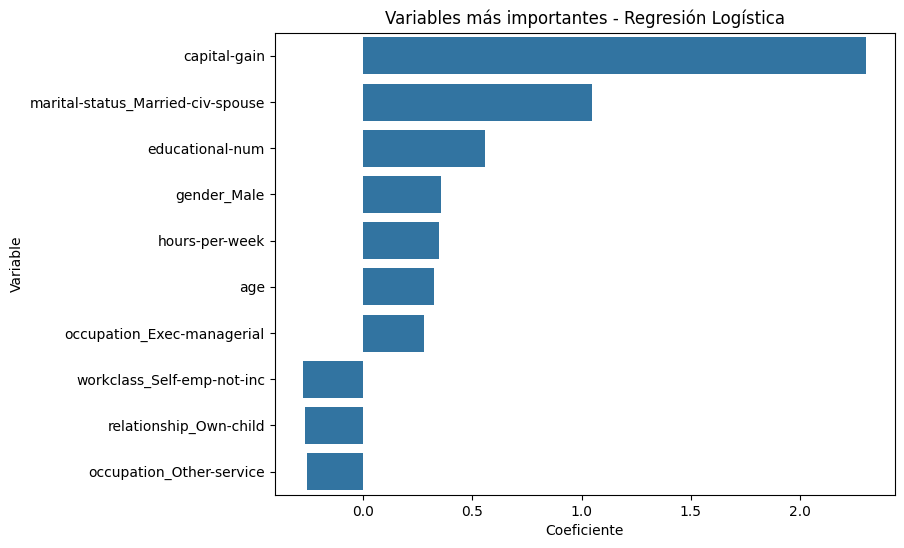

In [12]:
coeficientes = pd.DataFrame({
    "Variable": X.columns,
    "Coeficiente": log_reg.coef_[0]
})

coeficientes["Valor absoluto"] = abs(coeficientes["Coeficiente"])
coeficientes = coeficientes.sort_values(
    by="Valor absoluto",
    ascending=False
)
top10 = coeficientes.head(10)

plt.figure(figsize=(8,6))
sns.barplot(
    data=top10,
    x="Coeficiente",
    y="Variable"
)
plt.title("Variables más importantes - Regresión Logística")
plt.show()

## **4. k-NEAREST NEIGHBORS (k-NN)**

### **4.1 DEFINICIÓN DE PARÁMETROS**

In [13]:
inicio_knn = time.time()
resultados_knn = []

for k in range(1, 31):

    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    y_pred = knn.predict(X_test_scaled)
    y_prob = knn.predict_proba(X_test_scaled)[:, 1]

    resultados_knn.append({
        "k": k,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "AUC-ROC": roc_auc_score(y_test, y_prob)
    })

resultados_knn_df = pd.DataFrame(resultados_knn)

mejor_k = resultados_knn_df.sort_values(by="F1-score", ascending=False).iloc[0]["k"]

print("Mejor valor de k:", mejor_k)

Mejor valor de k: 11.0


### **4.2 PREDICCIONES Y MÉTRICAS**

In [14]:
knn_final = KNeighborsClassifier(n_neighbors=int(mejor_k))
knn_final.fit(X_train_scaled, y_train)
y_pred_knn = knn_final.predict(X_test_scaled)
y_prob_knn = knn_final.predict_proba(X_test_scaled)[:, 1]
tiempo_knn = time.time() - inicio_knn

accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn)
recall_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)
auc_knn = roc_auc_score(y_test, y_prob_knn)

print("===== k-NN =====")
print("Accuracy:", accuracy_knn)
print("Precision:", precision_knn)
print("Recall:", recall_knn)
print("F1-score:", f1_knn)
print("AUC-ROC:", auc_knn)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

resultados_finales.append({
    "Modelo": "k-NN",
    "Accuracy": accuracy_knn,
    "Precision": precision_knn,
    "Recall": recall_knn,
    "F1-score": f1_knn,
    "AUC-ROC": auc_knn,
    "Tiempo (s)": tiempo_knn
})

===== k-NN =====
Accuracy: 0.8257600884466556
Precision: 0.6761904761904762
Recall: 0.5700267618198037
F1-score: 0.6185866408518877
AUC-ROC: 0.8549789061681478

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.91      0.89      6803
           1       0.68      0.57      0.62      2242

    accuracy                           0.83      9045
   macro avg       0.77      0.74      0.75      9045
weighted avg       0.82      0.83      0.82      9045



### **4.3 MATRIZ DE CONFUSIÓN Y CURVA ROC**

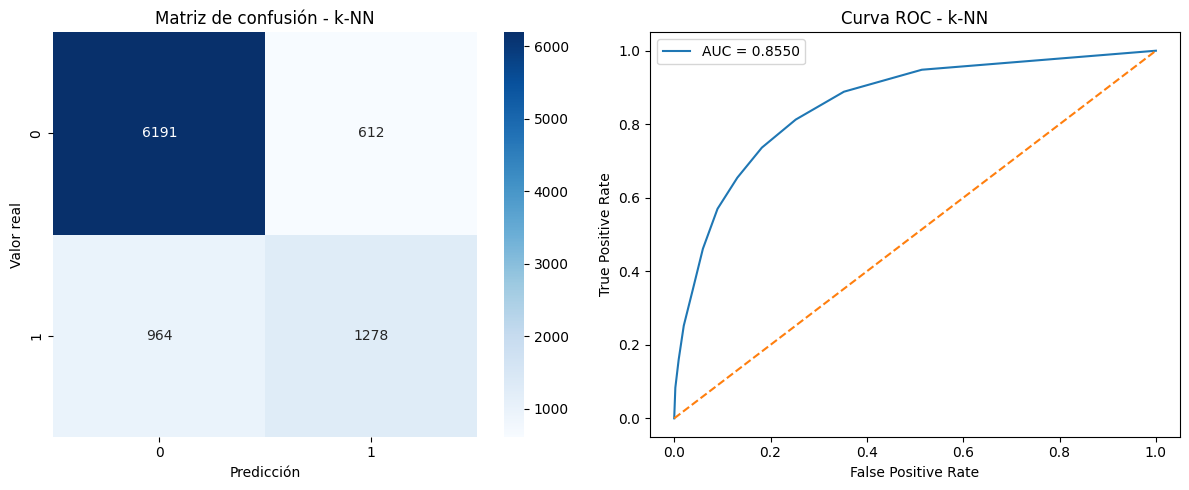

In [15]:
cm_knn = confusion_matrix(y_test, y_pred_knn)
fpr_knn, tpr_knn, thresholds_knn = roc_curve(y_test, y_prob_knn)

fig, ax = plt.subplots(1, 2, figsize=(12,5))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Blues",
    ax=ax[0]
)

ax[0].set_title("Matriz de confusión - k-NN")
ax[0].set_xlabel("Predicción")
ax[0].set_ylabel("Valor real")

ax[1].plot(
    fpr_knn,
    tpr_knn,
    label=f"AUC = {auc_knn:.4f}"
)
ax[1].plot([0,1], [0,1], linestyle="--")
ax[1].set_title("Curva ROC - k-NN")
ax[1].set_xlabel("False Positive Rate")
ax[1].set_ylabel("True Positive Rate")
ax[1].legend()

plt.tight_layout()
plt.show()

## **5. ÁRBOLES DE DECISIÓN**

### **5.1 DEFINICIÓN DE PARÁMETROS**




In [16]:
inicio_tree = time.time()

tree = DecisionTreeClassifier(
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=10, min_samples_leaf=10, min_samples_split=20,
                       random_state=42)

### **5.2 PREDICCIONES Y MÉTRICAS**

In [17]:
y_pred_tree = tree.predict(X_test)
y_prob_tree = tree.predict_proba(X_test)[:,1]
tiempo_tree = time.time() - inicio_tree

accuracy_tree = accuracy_score(y_test, y_pred_tree)
precision_tree = precision_score(y_test, y_pred_tree)
recall_tree = recall_score(y_test, y_pred_tree)
f1_tree = f1_score(y_test, y_pred_tree)
auc_tree = roc_auc_score(y_test, y_prob_tree)

print("===== ÁRBOL DE DECISIÓN =====\n")
print("Accuracy:", accuracy_tree)
print("Precision:", precision_tree)
print("Recall:", recall_tree)
print("F1-score:", f1_tree)
print("AUC-ROC:", auc_tree)

print("\n===== Classification Report =====\n")
print(classification_report(y_test, y_pred_tree))


resultados_finales.append({
    "Modelo": "Árbol de Decisión",
    "Accuracy": accuracy_tree,
    "Precision": precision_tree,
    "Recall": recall_tree,
    "F1-score": f1_tree,
    "AUC-ROC": auc_tree,
    "Tiempo (s)": tiempo_tree
})

===== ÁRBOL DE DECISIÓN =====

Accuracy: 0.8505251520176893
Precision: 0.7488814317673378
Recall: 0.5972346119536128
F1-score: 0.6645161290322581
AUC-ROC: 0.898954133290883

===== Classification Report =====

              precision    recall  f1-score   support

           0       0.88      0.93      0.90      6803
           1       0.75      0.60      0.66      2242

    accuracy                           0.85      9045
   macro avg       0.81      0.77      0.78      9045
weighted avg       0.84      0.85      0.84      9045



### **5.3 MATRIZ DE CONFUSIÓN Y CURVA ROC**

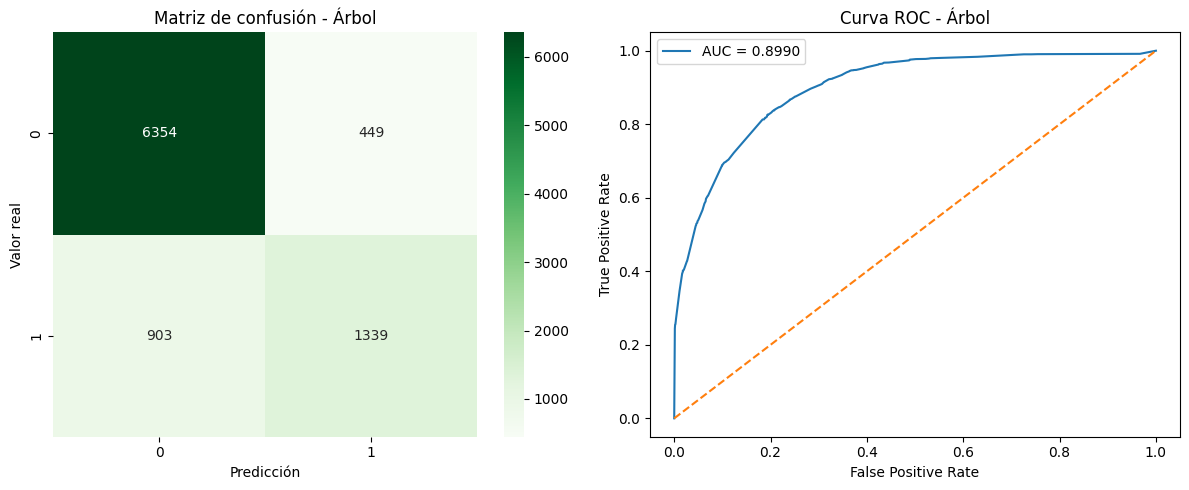

In [18]:
cm_tree = confusion_matrix(y_test, y_pred_tree)

fpr_tree, tpr_tree, thresholds_tree = roc_curve(
    y_test,
    y_prob_tree
)

fig, ax = plt.subplots(1, 2, figsize=(12,5))

# MATRIZ

sns.heatmap(
    cm_tree,
    annot=True,
    fmt="d",
    cmap="Greens",
    ax=ax[0]
)

ax[0].set_title("Matriz de confusión - Árbol")
ax[0].set_xlabel("Predicción")
ax[0].set_ylabel("Valor real")

# ROC

ax[1].plot(
    fpr_tree,
    tpr_tree,
    label=f"AUC = {auc_tree:.4f}"
)

ax[1].plot([0,1], [0,1], linestyle="--")

ax[1].set_title("Curva ROC - Árbol")
ax[1].set_xlabel("False Positive Rate")
ax[1].set_ylabel("True Positive Rate")

ax[1].legend()

plt.tight_layout()
plt.show()

### **5.4 IMPORTANCIA DE VARIABLES**

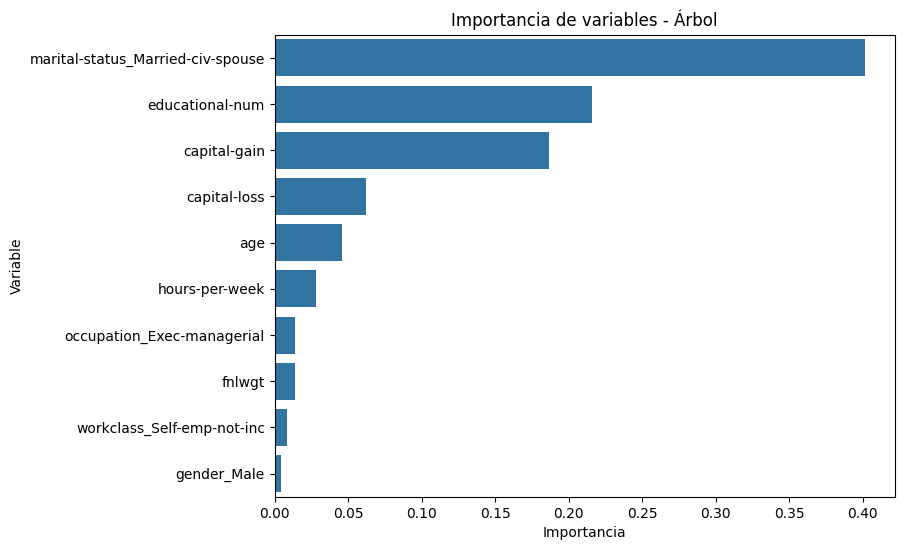

In [19]:
importancias = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": tree.feature_importances_
})

importancias = importancias.sort_values(
    by="Importancia",
    ascending=False
)

importancias.head(10)
top10 = importancias.head(10)

plt.figure(figsize=(8,6))

sns.barplot(
    data=top10,
    x="Importancia",
    y="Variable"
)

plt.title("Importancia de variables - Árbol")

plt.show()

### **5.5 VISUALIZACIÓN**

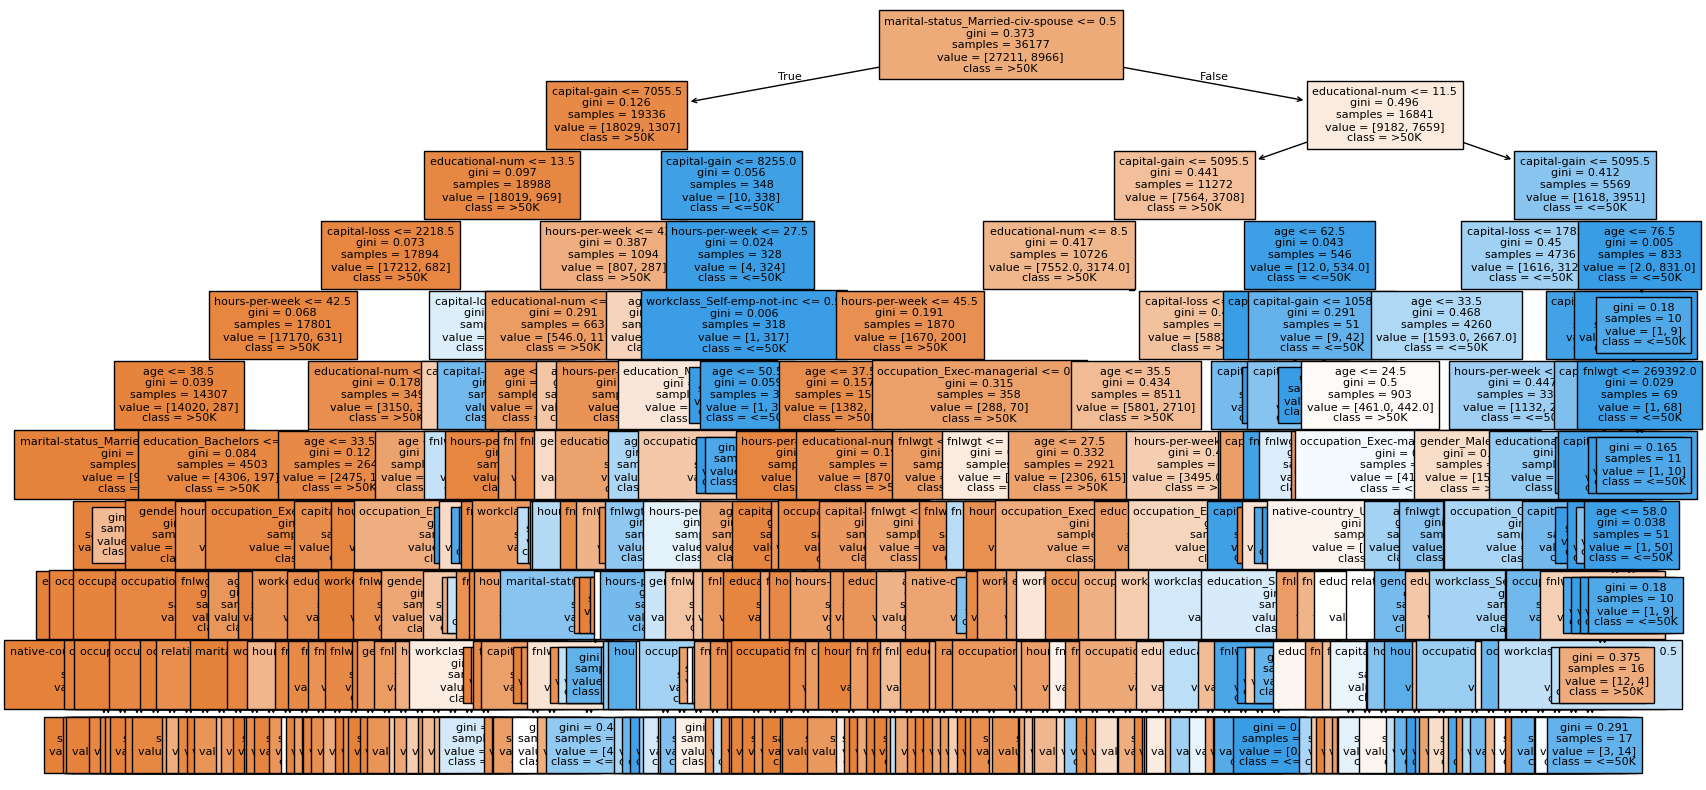

In [20]:
plt.figure(figsize=(20,10))

plot_tree(
    tree,
    feature_names=X.columns,
    class_names=[">50K", "<=50K"],
    filled=True,
    fontsize=8
)

plt.show()

## **6. RANDOM FOREST**

### **6.1 DEFINICIÓN DE PARÁMETROS**

In [21]:
inicio_rf = time.time()
resultados_rf = []
valores_estimators = [100, 200]
valores_depth = [10, 20, None]

for n in valores_estimators:
    for depth in valores_depth:
        rf = RandomForestClassifier(
            n_estimators=n,
            max_depth=depth,
            random_state=42,
            n_jobs=-1
        )
        rf.fit(X_train, y_train)
        y_pred = rf.predict(X_test)
        y_prob = rf.predict_proba(X_test)[:,1]
        resultados_rf.append({
            "n_estimators": n,
            "max_depth": depth,
            "Accuracy": accuracy_score(y_test, y_pred),
            "F1-score": f1_score(y_test, y_pred),
            "AUC-ROC": roc_auc_score(y_test, y_prob)
        })

resultados_rf_df = pd.DataFrame(resultados_rf)
mejor_rf = resultados_rf_df.sort_values(
    by="F1-score",
    ascending=False
).iloc[0]
best_n = int(mejor_rf["n_estimators"])
best_depth = mejor_rf["max_depth"]
if pd.notnull(best_depth):
    best_depth = int(best_depth)
else:
    best_depth = None

rf_final = RandomForestClassifier(
    n_estimators=best_n,
    max_depth=best_depth,
    random_state=42,
    n_jobs=-1
)
rf_final.fit(X_train, y_train)

RandomForestClassifier(max_depth=20, n_jobs=-1, random_state=42)

### **6.2 PREDICCIONES Y MÉTRICAS**

In [22]:
y_pred_rf = rf_final.predict(X_test)
y_prob_rf = rf_final.predict_proba(X_test)[:, 1]
tiempo_rf = time.time() - inicio_rf

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)

print("===== RANDOM FOREST =====\n")

print("Accuracy:", accuracy_rf)
print("Precision:", precision_rf)
print("Recall:", recall_rf)
print("F1-score:", f1_rf)
print("AUC-ROC:", auc_rf)

print("\n===== Classification Report =====\n")
print(classification_report(y_test, y_pred_rf))

resultados_finales.append({
    "Modelo": "Random Forest",
    "Accuracy": accuracy_rf,
    "Precision": precision_rf,
    "Recall": recall_rf,
    "F1-score": f1_rf,
    "AUC-ROC": auc_rf,
    "Tiempo (s)": tiempo_rf
})

===== RANDOM FOREST =====

Accuracy: 0.8576008844665561
Precision: 0.7835909631391201
Recall: 0.5878679750223015
F1-score: 0.6717635066258919
AUC-ROC: 0.9146397408500184

===== Classification Report =====

              precision    recall  f1-score   support

           0       0.87      0.95      0.91      6803
           1       0.78      0.59      0.67      2242

    accuracy                           0.86      9045
   macro avg       0.83      0.77      0.79      9045
weighted avg       0.85      0.86      0.85      9045



### **6.3 MATRIZ DE CONFUSIÓN Y CURVA ROC**

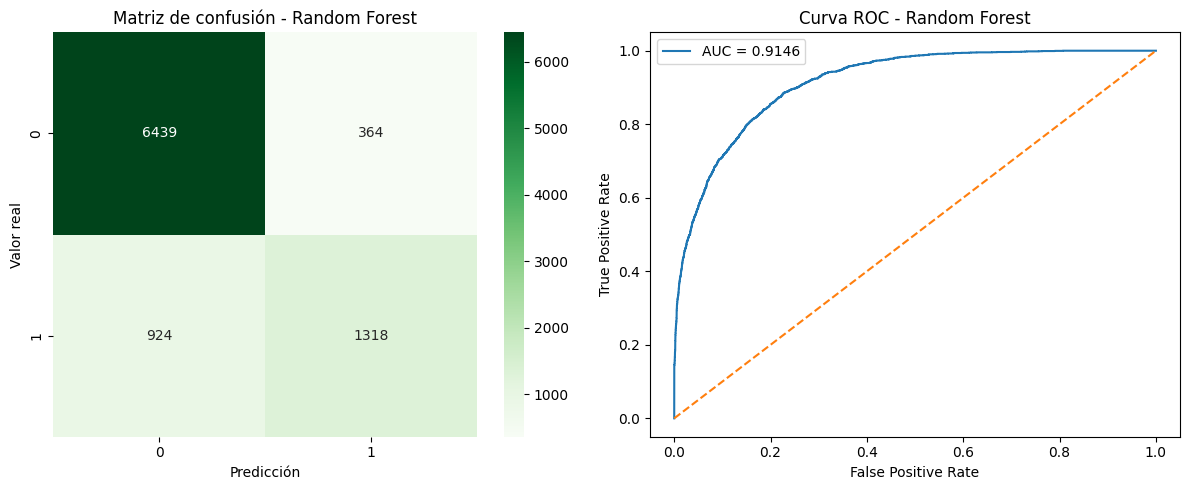

In [23]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_prob_rf)

fig, ax = plt.subplots(1, 2, figsize=(12,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens",
    ax=ax[0]
)

ax[0].set_title("Matriz de confusión - Random Forest")
ax[0].set_xlabel("Predicción")
ax[0].set_ylabel("Valor real")

ax[1].plot(
    fpr_rf,
    tpr_rf,
    label=f"AUC = {auc_rf:.4f}"
)
ax[1].plot([0, 1], [0, 1], linestyle="--")
ax[1].set_title("Curva ROC - Random Forest")
ax[1].set_xlabel("False Positive Rate")
ax[1].set_ylabel("True Positive Rate")
ax[1].legend()

plt.tight_layout()
plt.show()

### **6.4 IMPORTANCIA DE VARIABLES**

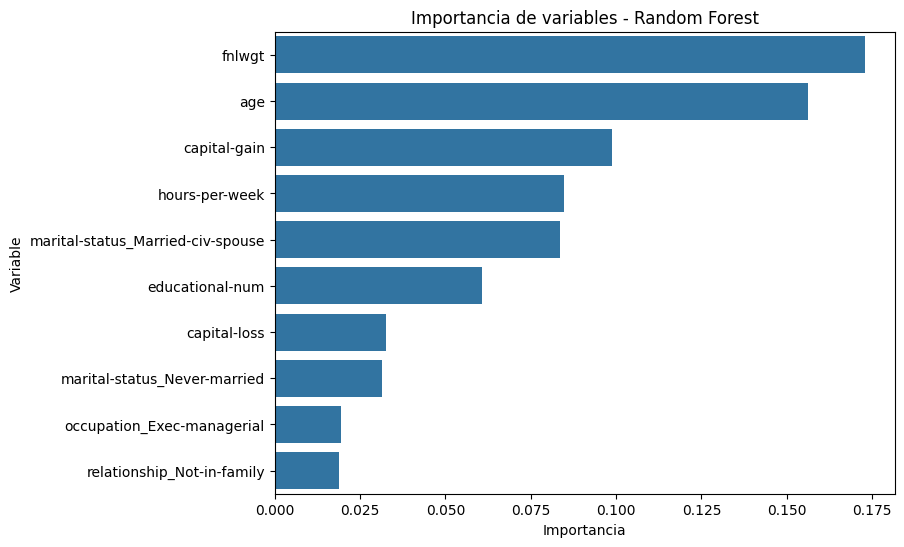

In [24]:
importancias_rf = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": rf.feature_importances_
})

importancias_rf = importancias_rf.sort_values(
    by="Importancia",
    ascending=False
)

top10_rf = importancias_rf.head(10)

plt.figure(figsize=(8,6))

sns.barplot(
    data=top10_rf,
    x="Importancia",
    y="Variable"
)

plt.title("Importancia de variables - Random Forest")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()

## **7. XGBOOST**

### **7.1 DEFINICIÓN DE PARÁMETROS**

In [25]:
inicio_xgb = time.time()
xgb_base = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

# Espacio de hiperparámetros
param_grid_xgb = {
    "n_estimators": [50, 100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [2, 3, 4, 5, 6],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "gamma": [0, 0.1, 0.2, 0.5],
    "reg_alpha": [0, 0.01, 0.1, 1],
    "reg_lambda": [0.5, 1, 2, 5]
}

# Randomized Search
xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid_xgb,
    n_iter=50,
    scoring="f1",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_search.fit(X_train, y_train)

print("Mejores hiperparámetros:")
print(xgb_search.best_params_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Mejores hiperparámetros:
{'subsample': 0.8, 'reg_lambda': 5, 'reg_alpha': 0, 'n_estimators': 300, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 0.5, 'colsample_bytree': 1.0}


### **7.2 PREDICCIONES Y MÉTRICAS**

In [26]:
xgb_final = xgb_search.best_estimator_
y_pred_xgb = xgb_final.predict(X_test)
y_prob_xgb = xgb_final.predict_proba(X_test)[:, 1]
tiempo_xgb = time.time() - inicio_xgb

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print("===== XGBOOST =====\n")

print("Accuracy:", accuracy_xgb)
print("Precision:", precision_xgb)
print("Recall:", recall_xgb)
print("F1-score:", f1_xgb)
print("AUC-ROC:", auc_xgb)

print("\n===== Classification Report =====\n")
print(classification_report(y_test, y_pred_xgb))

resultados_finales.append({
    "Modelo": "XGBoost",
    "Accuracy": accuracy_xgb,
    "Precision": precision_xgb,
    "Recall": recall_xgb,
    "F1-score": f1_xgb,
    "AUC-ROC": auc_xgb,
    "Tiempo (s)": tiempo_xgb
})

===== XGBOOST =====

Accuracy: 0.867551133222775
Precision: 0.7738719832109129
Recall: 0.6578947368421053
F1-score: 0.7111861137897783
AUC-ROC: 0.9264563319719235

===== Classification Report =====

              precision    recall  f1-score   support

           0       0.89      0.94      0.91      6803
           1       0.77      0.66      0.71      2242

    accuracy                           0.87      9045
   macro avg       0.83      0.80      0.81      9045
weighted avg       0.86      0.87      0.86      9045



### **7.3 MATRIZ DE CONFUSIÓN Y CURVA ROC**

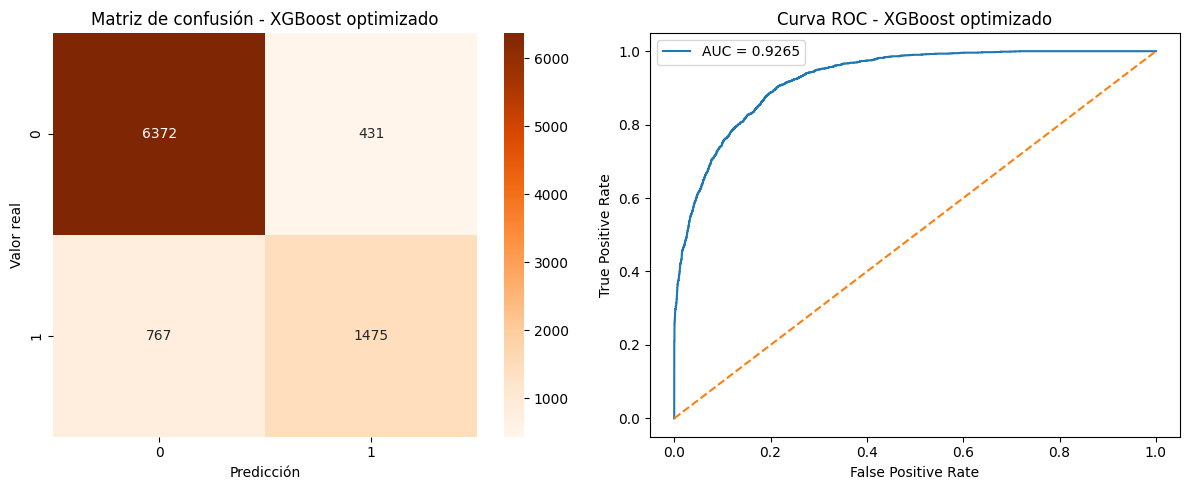

In [27]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, y_prob_xgb)

fig, ax = plt.subplots(1, 2, figsize=(12,5))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    cmap="Oranges",
    ax=ax[0]
)

ax[0].set_title("Matriz de confusión - XGBoost optimizado")
ax[0].set_xlabel("Predicción")
ax[0].set_ylabel("Valor real")

ax[1].plot(
    fpr_xgb,
    tpr_xgb,
    label=f"AUC = {auc_xgb:.4f}"
)
ax[1].plot([0, 1], [0, 1], linestyle="--")
ax[1].set_title("Curva ROC - XGBoost optimizado")
ax[1].set_xlabel("False Positive Rate")
ax[1].set_ylabel("True Positive Rate")
ax[1].legend()

plt.tight_layout()
plt.show()

### **7.4 IMPORTANCIA DE VARIABLES**

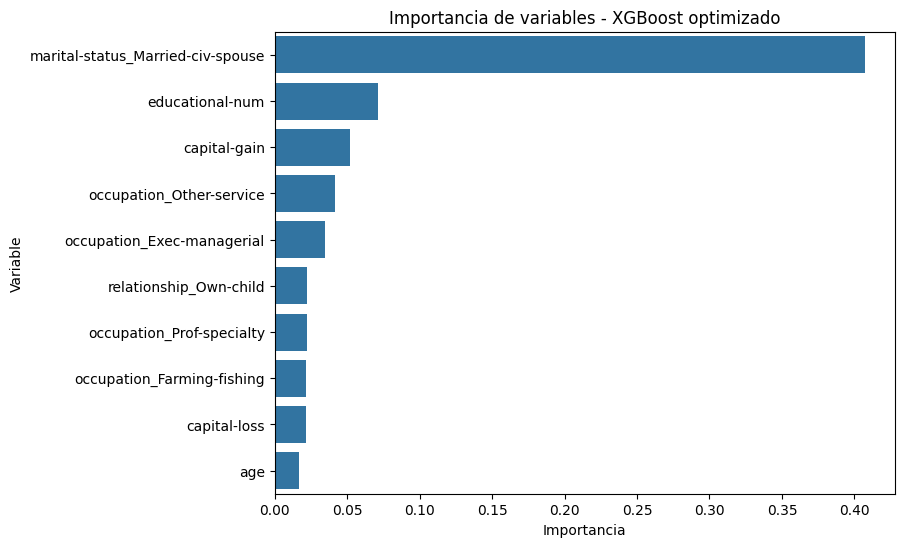

In [28]:
importancias_xgb = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": xgb_final.feature_importances_
}).sort_values(by="Importancia", ascending=False)

top10_xgb = importancias_xgb.head(10)

plt.figure(figsize=(8,6))

sns.barplot(
    data=top10_xgb,
    x="Importancia",
    y="Variable"
)

plt.title("Importancia de variables - XGBoost optimizado")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.show()

## **8. RED NEURONAL**

## **8.1 DIVISIÓN TRAIN-TEST**

In [29]:
inicio_mlp = time.time()
np.random.seed(42)

X_train_nn = X_train_scaled.T
X_test_nn = X_test_scaled.T

y_train_nn = np.array(y_train).reshape(1, -1)
y_test_nn = np.array(y_test).reshape(1, -1)

print("X_train_nn:", X_train_nn.shape)
print("y_train_nn:", y_train_nn.shape)
print("X_test_nn:", X_test_nn.shape)
print("y_test_nn:", y_test_nn.shape)

X_train_nn: (96, 36177)
y_train_nn: (1, 36177)
X_test_nn: (96, 9045)
y_test_nn: (1, 9045)


## **8.2 FUNCIONES DE ACTIVACIÓN**

In [30]:
def sigmoid(Z):
    A = 1 / (1 + np.exp(-Z))
    return A, Z

def relu(Z):
    A = np.maximum(0, Z)
    return A, Z

def relu_backward(dA, Z):
    dZ = np.array(dA, copy=True)
    dZ[Z <= 0] = 0
    return dZ

def sigmoid_backward(dA, Z):
    A = 1 / (1 + np.exp(-Z))
    dZ = dA * A * (1 - A)
    return dZ

## **8.3 DEFINICIÓN DE FUNCIONES:**


*   Inizialización de parámetros
*   Propagación hacia delante


*   Función de coste
*   Propagación hacia atrás

*   Actualización de parámetros
*   Desarrollo del modelo


*   Función de predicción








In [31]:
# 1. Inizialización de parámetros

def initialize_parameters_he(layer_dims):
    np.random.seed(42)
    parameters = {}
    L = len(layer_dims)
    for l in range(1, L):
        parameters["W" + str(l)] = np.random.randn(
            layer_dims[l],
            layer_dims[l-1]
        ) * np.sqrt(2 / layer_dims[l-1])
        parameters["b" + str(l)] = np.zeros((layer_dims[l], 1))
    return parameters

# 2. Propagación hacia delante

def linear_forward(A_prev, W, b):
    Z = np.dot(W, A_prev) + b
    cache = (A_prev, W, b)
    return Z, cache

def linear_activation_forward(A_prev, W, b, activation):
    Z, linear_cache = linear_forward(A_prev, W, b)
    if activation == "relu":
        A, activation_cache = relu(Z)
    elif activation == "sigmoid":
        A, activation_cache = sigmoid(Z)
    cache = (linear_cache, activation_cache)
    return A, cache

def L_model_forward(X, parameters):
    caches = []
    A = X
    L = len(parameters) // 2
    for l in range(1, L):
        A_prev = A
        A, cache = linear_activation_forward(
            A_prev,
            parameters["W" + str(l)],
            parameters["b" + str(l)],
            activation="relu"
        )
        caches.append(cache)
    AL, cache = linear_activation_forward(
        A,
        parameters["W" + str(L)],
        parameters["b" + str(L)],
        activation="sigmoid"
    )
    caches.append(cache)
    return AL, caches

# 3. Función de coste

def compute_cost(AL, Y, parameters=None, lambd=0):
    m = Y.shape[1]
    epsilon = 1e-8
    cross_entropy_cost = -1/m * np.sum(
        Y * np.log(AL + epsilon) + (1 - Y) * np.log(1 - AL + epsilon)
    )
    L2_cost = 0
    if lambd > 0 and parameters is not None:
        L = len(parameters) // 2
        for l in range(1, L + 1):
            L2_cost += np.sum(np.square(parameters["W" + str(l)]))
        L2_cost = (lambd / (2 * m)) * L2_cost
    cost = cross_entropy_cost + L2_cost
    return np.squeeze(cost)

# 4. Propagación hacia detrás

def linear_backward(dZ, cache, lambd=0):
    A_prev, W, b = cache
    m = A_prev.shape[1]
    dW = 1/m * np.dot(dZ, A_prev.T) + (lambd / m) * W
    db = 1/m * np.sum(dZ, axis=1, keepdims=True)
    dA_prev = np.dot(W.T, dZ)
    return dA_prev, dW, db

def linear_activation_backward(dA, cache, activation, lambd=0):
    linear_cache, activation_cache = cache
    if activation == "relu":
        dZ = relu_backward(dA, activation_cache)
    elif activation == "sigmoid":
        dZ = sigmoid_backward(dA, activation_cache)
    dA_prev, dW, db = linear_backward(dZ, linear_cache, lambd)
    return dA_prev, dW, db

def L_model_backward(AL, Y, caches, lambd=0):
    grads = {}
    L = len(caches)
    Y = Y.reshape(AL.shape)
    epsilon = 1e-8

    # Derivada inicial respecto a AL
    dAL = - (np.divide(Y, AL + epsilon) - np.divide(1 - Y, 1 - AL + epsilon))

    # Última capa: SIGMOID
    current_cache = caches[L - 1]
    dA_prev, dW, db = linear_activation_backward(
        dAL,
        current_cache,
        activation="sigmoid",
        lambd=lambd
    )
    grads["dA" + str(L-1)] = dA_prev
    grads["dW" + str(L)] = dW
    grads["db" + str(L)] = db

    # Capas ocultas: RELU
    for l in reversed(range(L - 1)):
        current_cache = caches[l]
        dA_prev, dW, db = linear_activation_backward(
            grads["dA" + str(l + 1)],
            current_cache,
            activation="relu",
            lambd=lambd
        )
        grads["dA" + str(l)] = dA_prev
        grads["dW" + str(l + 1)] = dW
        grads["db" + str(l + 1)] = db
    return grads

# 5. Actualización de parámetros

def update_parameters(parameters, grads, learning_rate):
    L = len(parameters) // 2
    for l in range(1, L + 1):
        parameters["W" + str(l)] -= learning_rate * grads["dW" + str(l)]
        parameters["b" + str(l)] -= learning_rate * grads["db" + str(l)]
    return parameters

# 6. Modelo completo

def L_layer_model(
    X,
    Y,
    layer_dims,
    learning_rate,
    num_iterations,
    lambd,
    print_cost=True
):
    np.random.seed(42)
    costs = []
    parameters = initialize_parameters_he(layer_dims)
    for i in range(num_iterations):

        # Forward propagation
        AL, caches = L_model_forward(X, parameters)

        # Coste
        cost = compute_cost(AL, Y, parameters, lambd)

        # Backpropagation
        grads = L_model_backward(AL, Y, caches, lambd)

        # Actualización de parámetros
        parameters = update_parameters(parameters, grads, learning_rate)

        if i % 100 == 0:
            costs.append(cost)
            if print_cost:
                print(f"Cost after iteration {i}: {cost}")
    return parameters, costs

# 7. Función de predicción

def predict(X, parameters, threshold):
    AL, _ = L_model_forward(X, parameters)
    predictions = (AL >= threshold).astype(int)
    return predictions, AL

## **8.4 BÚSQUEDA DE HIPERPARÁMETROS**

In [32]:
resultados_mlp = []

arquitecturas = [
    [X_train_nn.shape[0], 32, 16, 1],
    [X_train_nn.shape[0], 64, 32, 1],
    [X_train_nn.shape[0], 128, 64, 32, 1]
]

learning_rates = [0.01, 0.001]
num_iterations_list = [2000, 3000]
lambdas = [0, 0.01]
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

for arquitectura in arquitecturas:
    for lr in learning_rates:
        for num_iter in num_iterations_list:
            for lambd_value in lambdas:

                parameters_temp, costs_temp = L_layer_model(
                    X_train_nn,
                    y_train_nn,
                    layer_dims=arquitectura,
                    learning_rate=lr,
                    num_iterations=num_iter,
                    lambd=lambd_value,
                    print_cost=False
                )

                # Probabilidades del modelo
                _, y_prob_temp_nn = predict(
                    X_test_nn,
                    parameters_temp,
                    threshold=0.5
                )

                y_prob_temp = y_prob_temp_nn.ravel()

                # Probar distintos thresholds sobre las mismas probabilidades
                for threshold in thresholds:

                    y_pred_temp = (y_prob_temp >= threshold).astype(int)

                    resultados_mlp.append({
                        "Arquitectura": str(arquitectura),
                        "Learning Rate": lr,
                        "Iteraciones": num_iter,
                        "Lambda L2": lambd_value,
                        "Threshold": threshold,
                        "Accuracy": accuracy_score(y_test, y_pred_temp),
                        "Precision": precision_score(y_test, y_pred_temp, zero_division=0),
                        "Recall": recall_score(y_test, y_pred_temp, zero_division=0),
                        "F1-score": f1_score(y_test, y_pred_temp, zero_division=0),
                        "AUC-ROC": roc_auc_score(y_test, y_prob_temp),
                        "Coste final": costs_temp[-1]
                    })

resultados_mlp_df = pd.DataFrame(resultados_mlp)

resultados_mlp_df.sort_values(
    by="F1-score",
    ascending=False
).head(5)

,Arquitectura,Learning Rate,Iteraciones,Lambda L2,Threshold,Accuracy,Precision,Recall,F1-score,AUC-ROC,Coste final
51,"[96, 64, 32, 1]",0.01,3000,0.00,0.4,0.831841,0.647203,0.706958,0.675762,0.892379,0.334055
56,"[96, 64, 32, 1]",0.01,3000,0.01,0.4,0.831841,0.647203,0.706958,0.675762,0.892379,0.334083
55,"[96, 64, 32, 1]",0.01,3000,0.01,0.3,0.808624,0.583252,0.798394,0.674073,0.892379,0.334083
50,"[96, 64, 32, 1]",0.01,3000,0.00,0.3,0.808624,0.583252,0.798394,0.674073,0.892379,0.334055
90,"[96, 128, 64, 32, 1]",0.01,3000,0.00,0.3,0.810171,0.587007,0.789920,0.673512,0.891434,0.331680


### **8.4.1 Selección del mejor modelo con los hiperparámetros**

In [33]:
mejor_mlp = resultados_mlp_df.sort_values(
    by="F1-score",
    ascending=False
).iloc[0]

print("Mejor configuración encontrada:")
print(mejor_mlp)

best_architecture = eval(mejor_mlp["Arquitectura"])
best_learning_rate = mejor_mlp["Learning Rate"]
best_iterations = int(mejor_mlp["Iteraciones"])
best_lambda = mejor_mlp["Lambda L2"]
best_threshold = mejor_mlp["Threshold"]

Mejor configuración encontrada:
Arquitectura     [96, 64, 32, 1]
Learning Rate               0.01
Iteraciones                 3000
Lambda L2                    0.0
Threshold                    0.4
Accuracy                0.831841
Precision               0.647203
Recall                  0.706958
F1-score                0.675762
AUC-ROC                 0.892379
Coste final             0.334055
Name: 51, dtype: object


## **8.5 ENTRENAMIENTO DEL MODELO CON LOS HIPERPARÁMETROS**

In [34]:
parameters_mlp, costs_mlp = L_layer_model(
    X_train_nn,
    y_train_nn,
    layer_dims=best_architecture,
    learning_rate=best_learning_rate,
    num_iterations=best_iterations,
    lambd=best_lambda,
    print_cost=True
)

Cost after iteration 0: 0.7296117916838708
Cost after iteration 100: 0.5093745593747415
Cost after iteration 200: 0.44802841026795626
Cost after iteration 300: 0.4170505545702792
Cost after iteration 400: 0.39865316819536706
Cost after iteration 500: 0.38646788980930397
Cost after iteration 600: 0.3777857055324717
Cost after iteration 700: 0.37127452820466045
Cost after iteration 800: 0.36619056458621474
Cost after iteration 900: 0.3620885028141208
Cost after iteration 1000: 0.3587206219935213
Cost after iteration 1100: 0.3559121627808939
Cost after iteration 1200: 0.3535366735395345
Cost after iteration 1300: 0.3514773966370074
Cost after iteration 1400: 0.349661752191337
Cost after iteration 1500: 0.3480413581318096
Cost after iteration 1600: 0.3465642174149718
Cost after iteration 1700: 0.34520317288274466
Cost after iteration 1800: 0.3439437571627827
Cost after iteration 1900: 0.3427692666508293
Cost after iteration 2000: 0.34167056789280176
Cost after iteration 2100: 0.34064215613

## **8.6 CURVA DE COSTE**

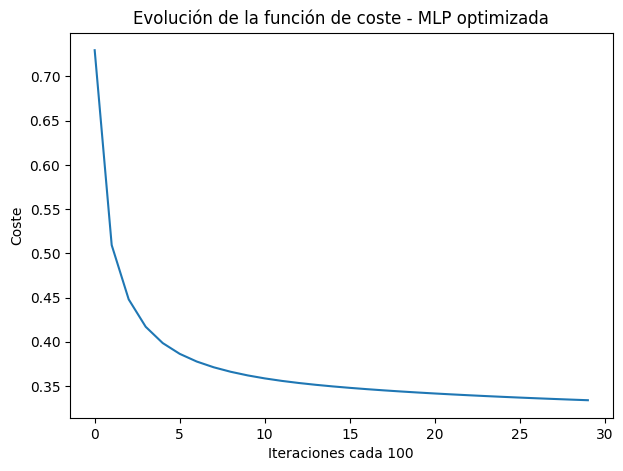

In [35]:
plt.figure(figsize=(7,5))
plt.plot(costs_mlp)
plt.xlabel("Iteraciones cada 100")
plt.ylabel("Coste")
plt.title("Evolución de la función de coste - MLP optimizada")
plt.show()

## **8.7 PREDICCIONES Y MÉTRICAS**

In [36]:
y_pred_mlp_nn, y_prob_mlp_nn = predict(X_test_nn, parameters_mlp, threshold=best_threshold)

y_pred_mlp = y_pred_mlp_nn.ravel()
y_prob_mlp = y_prob_mlp_nn.ravel()
tiempo_mlp = time.time() - inicio_mlp

accuracy_mlp = accuracy_score(y_test, y_pred_mlp)
precision_mlp = precision_score(y_test, y_pred_mlp, zero_division=0)
recall_mlp = recall_score(y_test, y_pred_mlp, zero_division=0)
f1_mlp = f1_score(y_test, y_pred_mlp, zero_division=0)
auc_mlp = roc_auc_score(y_test, y_prob_mlp)

print("===== RED NEURONAL MLP =====\n")

print("Mejor arquitectura:", best_architecture)
print("Learning rate:", best_learning_rate)
print("Iteraciones:", best_iterations)
print("Lambda L2:", best_lambda)
print("Threshold:", best_threshold)

print("\nAccuracy:", accuracy_mlp)
print("Precision:", precision_mlp)
print("Recall:", recall_mlp)
print("F1-score:", f1_mlp)
print("AUC-ROC:", auc_mlp)

print("\n===== Classification Report =====\n")
print(classification_report(y_test, y_pred_mlp, zero_division=0))

resultados_finales.append({
    "Modelo": "Red Neuronal MLP",
    "Accuracy": accuracy_mlp,
    "Precision": precision_mlp,
    "Recall": recall_mlp,
    "F1-score": f1_mlp,
    "AUC-ROC": auc_mlp,
    "Tiempo (s)": tiempo_mlp
})

===== RED NEURONAL MLP =====

Mejor arquitectura: [96, 64, 32, 1]
Learning rate: 0.01
Iteraciones: 3000
Lambda L2: 0.0
Threshold: 0.4

Accuracy: 0.8318407960199005
Precision: 0.6472029399755002
Recall: 0.7069580731489741
F1-score: 0.6757620976337668
AUC-ROC: 0.8923793656128253

===== Classification Report =====

              precision    recall  f1-score   support

           0       0.90      0.87      0.89      6803
           1       0.65      0.71      0.68      2242

    accuracy                           0.83      9045
   macro avg       0.77      0.79      0.78      9045
weighted avg       0.84      0.83      0.83      9045



## **8.8 MATRIZ DE CONFUSIÓN Y CURVA ROC**

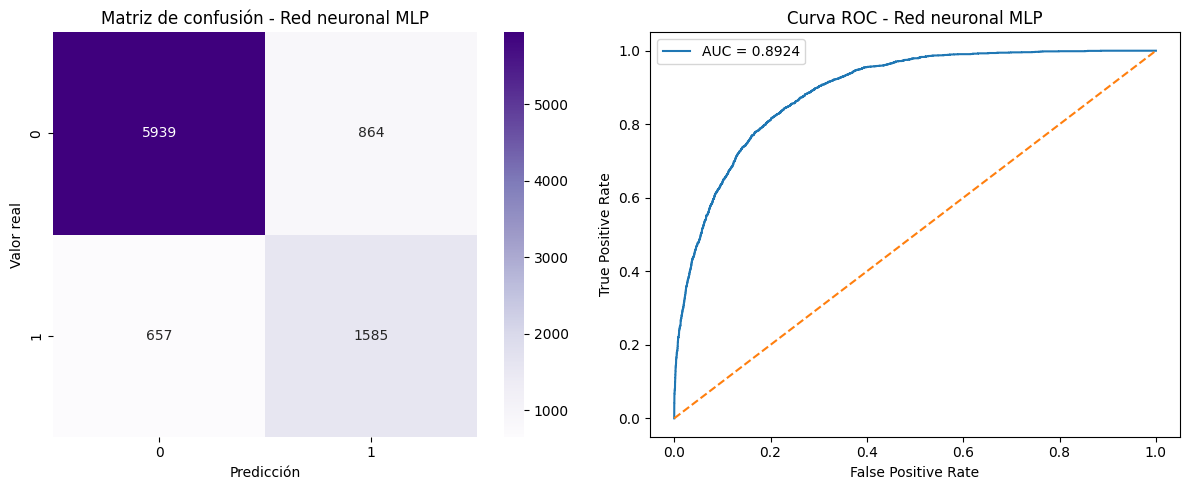

In [37]:
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
fpr_mlp, tpr_mlp, thresholds_mlp = roc_curve(y_test, y_prob_mlp)

fig, ax = plt.subplots(1, 2, figsize=(12,5))

sns.heatmap(
    cm_mlp,
    annot=True,
    fmt="d",
    cmap="Purples",
    ax=ax[0]
)

ax[0].set_title("Matriz de confusión - Red neuronal MLP")
ax[0].set_xlabel("Predicción")
ax[0].set_ylabel("Valor real")

ax[1].plot(
    fpr_mlp,
    tpr_mlp,
    label=f"AUC = {auc_mlp:.4f}"
)

ax[1].plot([0, 1], [0, 1], linestyle="--")

ax[1].set_title("Curva ROC - Red neuronal MLP")
ax[1].set_xlabel("False Positive Rate")
ax[1].set_ylabel("True Positive Rate")
ax[1].legend()

plt.tight_layout()
plt.show()

# **9. COMPARACIÓN DE MODELOS**

In [38]:
tabla_resultados = pd.DataFrame(resultados_finales)

tabla_resultados["Interpretabilidad"] = [
    "Sí",   # Regresión Logística
    "No",   # k-NN
    "Sí",   # Árbol
    "Sí",   # Random Forest
    "Sí",   # XGBoost
    "No"    # Red neuronal
]

tabla_resultados = tabla_resultados.sort_values(
    by="F1-score",
    ascending=False
)

tabla_resultados = tabla_resultados.reset_index(drop=True)

tabla_resultados.round(4)

,Modelo,Accuracy,Precision,Recall,F1-score,AUC-ROC,Tiempo (s),Interpretabilidad
0,XGBoost,0.8676,0.7739,0.6579,0.7112,0.9265,358.0717,Sí
1,Red Neuronal MLP,0.8318,0.6472,0.7070,0.6758,0.8924,16299.6961,No
2,Random Forest,0.8576,0.7836,0.5879,0.6718,0.9146,51.1144,Sí
3,Árbol de Decisión,0.8505,0.7489,0.5972,0.6645,0.8990,0.3871,Sí
4,Regresión Logística,0.8458,0.7305,0.5986,0.6580,0.9046,0.8976,Sí
5,k-NN,0.8258,0.6762,0.5700,0.6186,0.8550,313.9741,No
